In [23]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
folder_path = "12k 0 load data"
data_dictionary = {}

In [2]:
for root, dirs, files in os.walk ("12k 0 load data", topdown=False):
    for file_name in files:
        path=os.path.join(root, file_name)
        print(path)

12k 0 load data\Normal.mat
12k 0 load data\07 B.mat
12k 0 load data\14 B.mat
12k 0 load data\21 B.mat
12k 0 load data\28 B.mat
12k 0 load data\07 IR.mat
12k 0 load data\14 IR.mat
12k 0 load data\21 IR.mat
12k 0 load data\28 IR.mat
12k 0 load data\07 OR1.mat
12k 0 load data\07 OR2.mat
12k 0 load data\07 OR3.mat
12k 0 load data\14 OR.mat
12k 0 load data\21 OR1.mat
12k 0 load data\21 OR2.mat
12k 0 load data\21 OR3.mat


In [3]:
path=r"12k 0 load data\Normal.mat"
normal_signal=scipy.io.loadmat(path)

In [4]:
normal_signal.items()

dict_items([('__header__', b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 31 15:28:20 2000'), ('__version__', '1.0'), ('__globals__', []), ('X097_DE_time', array([[ 0.05319692],
       [ 0.08866154],
       [ 0.09971815],
       ...,
       [-0.03463015],
       [ 0.01668923],
       [ 0.04693846]], shape=(243938, 1))), ('X097_FE_time', array([[0.14566727],
       [0.09779636],
       [0.05485636],
       ...,
       [0.14053091],
       [0.09553636],
       [0.09019455]], shape=(243938, 1))), ('X097RPM', array([[1796]], dtype=uint16))])

In [5]:
list(normal_signal.keys())

['__header__',
 '__version__',
 '__globals__',
 'X097_DE_time',
 'X097_FE_time',
 'X097RPM']

In [6]:
key_name=list(normal_signal.keys())[3]


In [7]:
DE_data=normal_signal.get(key_name)

In [8]:
len(DE_data)
DE_data


array([[ 0.05319692],
       [ 0.08866154],
       [ 0.09971815],
       ...,
       [-0.03463015],
       [ 0.01668923],
       [ 0.04693846]], shape=(243938, 1))

In [10]:
file_name

'21 OR3.mat'

In [9]:
fault = np.full((len(DE_data),),1)

In [11]:
df_temp=pd.DataFrame({'DE_data': np.ravel(DE_data), 'fault': np.ravel(fault)})

In [12]:
df_temp

,DE_data,fault
0,0.053197,1
1,0.088662,1
2,0.099718,1
3,0.058621,1
4,-0.004590,1
...,...,...
243933,-0.059664,1
243934,-0.063836,1
243935,-0.034630,1
243936,0.016689,1


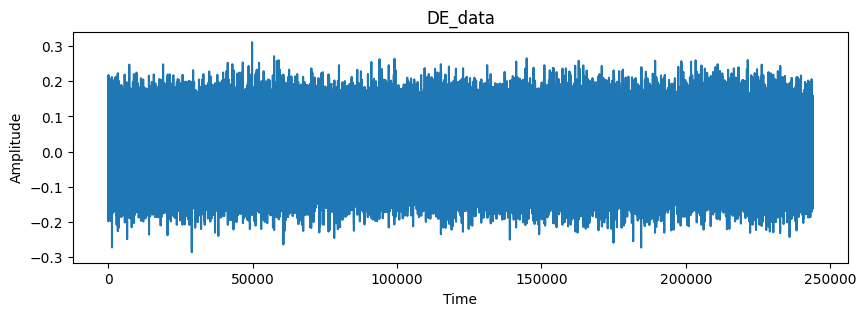

In [13]:
plt.figure(figsize=(10,3))
plt.plot(df_temp.iloc[:,0])
plt.title('DE_data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

In [19]:
df=pd.DataFrame(columns=['DE_data','fault'])

for root, dirs, files in os.walk ("12k 0 load data", topdown=True):
    for file_name in files:
        path=os.path.join(root, file_name)
        print(path)

        signal=scipy.io.loadmat(path)
        key_name=list(signal.keys())[3]
        DE_data=signal.get(key_name)
        fault = np.full((len(DE_data),),1)
        df_temp=pd.DataFrame({'DE_data': np.ravel(DE_data), 'fault': np.ravel(fault)})
        df=pd.concat([df, df_temp], axis=0)
        print(df['fault'].unique())

df.to_csv('0_load_data_12k.csv', index=False)


12k 0 load data\Normal.mat
[1]
12k 0 load data\07 B.mat
[1]
12k 0 load data\14 B.mat
[1]
12k 0 load data\21 B.mat
[1]
12k 0 load data\28 B.mat
[1]
12k 0 load data\07 IR.mat
[1]
12k 0 load data\14 IR.mat
[1]
12k 0 load data\21 IR.mat
[1]
12k 0 load data\28 IR.mat
[1]
12k 0 load data\07 OR1.mat
[1]
12k 0 load data\07 OR2.mat
[1]
12k 0 load data\07 OR3.mat
[1]
12k 0 load data\14 OR.mat
[1]
12k 0 load data\21 OR1.mat
[1]
12k 0 load data\21 OR2.mat
[1]
12k 0 load data\21 OR3.mat
[1]


In [20]:
df=pd.read_csv("0_load_data_12k.csv")

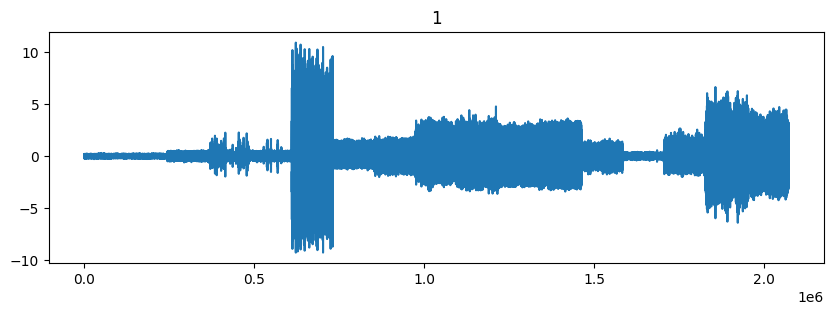

In [22]:
faults=df['fault'].unique()
for f in faults:
    plt.figure(figsize=(10,3))
    plt.plot(df[df['fault']==f].iloc[:,0])
    plt.title(f)
    plt.show()

    
